# Notebook 05 — Hybrid Stacking Ensemble
### THE KEY NOTEBOOK — Fixed GroupKFold OOF · No Meta-Level Leakage

**Why original stacking failed (R²=−0.47):**
1. Cell order: split ran BEFORE data load
2. `cv=5` random KFold → same patient in fold-train AND fold-val → meta leakage
3. Ridge meta-learner → too simple for nonlinear problem
4. `max_depth=4` for XGBoost → suboptimal

**What this notebook fixes:**
1. ✅ Data loaded first, split second
2. ✅ Subject-Wise GroupKFold (n_splits=5) for OOF
3. ✅ XGBoost meta-learner (depth=3, n_est=200)
4. ✅ XGBoost base learner with max_depth=5

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sklearn.base
from scipy import stats
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('✅ Libraries loaded')

✅ Libraries loaded


In [9]:
# ── STEP 1: LOAD DATA FIRST (critical — do NOT split before this) ──
df = pd.read_csv('../data/clean_parkinsons.csv')
print('✅ Data loaded:', df.shape)
print('Columns:', df.columns.tolist())

✅ Data loaded: (5875, 21)
Columns: ['subject#', 'age', 'sex', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


In [10]:
# ── STEP 2: Subject-Wise Split ─────────────────────────────
TARGET = 'total_UPDRS'
subjects = df['subject#'].unique()
train_subjects, test_subjects = train_test_split(subjects, test_size=0.2, random_state=42)

train_df = df[df['subject#'].isin(train_subjects)].reset_index(drop=True)
test_df  = df[df['subject#'].isin(test_subjects)].reset_index(drop=True)

# Save groups BEFORE dropping subject#
train_groups = train_df['subject#'].values

X_train = train_df.drop(columns=[TARGET, 'subject#'])
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=[TARGET, 'subject#'])
y_test  = test_df[TARGET]

print(f'Train: {X_train.shape} | {len(train_subjects)} subjects')
print(f'Test:  {X_test.shape}  | {len(test_subjects)} subjects: {sorted(test_subjects)}')

Train: (4640, 19) | 33 subjects
Test:  (1235, 19)  | 9 subjects: [np.int64(5), np.int64(9), np.int64(14), np.int64(20), np.int64(26), np.int64(27), np.int64(30), np.int64(31), np.int64(40)]


In [11]:
# ── STEP 3: Define Base Learners ───────────────────────────
# XGBoost: depth=5, n=300, lr=0.05 (best config, NO subsampling)
# SVR + MLP: wrapped in Pipeline WITH StandardScaler
base_learners = [
    ('RF',  RandomForestRegressor(n_estimators=200, random_state=42)),
    ('XGB', XGBRegressor(n_estimators=300, learning_rate=0.05,
                         max_depth=5, random_state=42, verbosity=0)),
    ('SVR', Pipeline([('scaler', StandardScaler()), ('svr', SVR())])),
    ('MLP', Pipeline([('scaler', StandardScaler()),
                      ('mlp', MLPRegressor(hidden_layer_sizes=(128,64),
                                           max_iter=1000, random_state=42))]))
]
print('Base Learners:')
for name, _ in base_learners:
    print(f'  {name}')

Base Learners:
  RF
  XGB
  SVR
  MLP


In [12]:
# ── STEP 4: Subject-Wise GroupKFold OOF Meta-Features ──────
# KEY: GroupKFold ensures each fold's validation = only UNSEEN subjects
# This prevents meta-level data leakage (vs random cv=5 in original)
print('Generating OOF Meta-Features (Subject-Wise GroupKFold, 5 folds)...')
print('='*65)

gkf = GroupKFold(n_splits=5)
meta_train = np.zeros((len(X_train), len(base_learners)))
fold_scores = {name: [] for name,_ in base_learners}

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=train_groups)):
    Xf_tr, yf_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    Xf_v,  yf_v  = X_train.iloc[val_idx], y_train.iloc[val_idx]
    val_subj = sorted(set(train_groups[val_idx]))
    print(f'\nFold {fold+1}/5 | Val subjects: {val_subj}')
    for i, (name, mdl) in enumerate(base_learners):
        m = sklearn.base.clone(mdl)
        m.fit(Xf_tr, yf_tr)
        oof = m.predict(Xf_v)
        meta_train[val_idx, i] = oof
        r2f = r2_score(yf_v, oof)
        fold_scores[name].append(r2f)
        print(f'  {name:<5}: fold R²={r2f:.4f}')

print(f'\n✅ OOF meta-feature matrix shape: {meta_train.shape}')

Generating OOF Meta-Features (Subject-Wise GroupKFold, 5 folds)...

Fold 1/5 | Val subjects: [np.int64(1), np.int64(2), np.int64(15), np.int64(29), np.int64(33), np.int64(36)]
  RF   : fold R²=0.5661
  XGB  : fold R²=0.5967
  SVR  : fold R²=0.8176
  MLP  : fold R²=0.6454

Fold 2/5 | Val subjects: [np.int64(11), np.int64(16), np.int64(18), np.int64(32), np.int64(35), np.int64(38), np.int64(42)]
  RF   : fold R²=0.8880
  XGB  : fold R²=0.8743
  SVR  : fold R²=0.8056
  MLP  : fold R²=0.8617

Fold 3/5 | Val subjects: [np.int64(8), np.int64(10), np.int64(12), np.int64(21), np.int64(23), np.int64(37), np.int64(41)]
  RF   : fold R²=0.7532
  XGB  : fold R²=0.7660
  SVR  : fold R²=0.6283
  MLP  : fold R²=0.6757

Fold 4/5 | Val subjects: [np.int64(3), np.int64(6), np.int64(7), np.int64(19), np.int64(25), np.int64(28)]
  RF   : fold R²=0.5755
  XGB  : fold R²=0.5850
  SVR  : fold R²=0.6573
  MLP  : fold R²=0.6869

Fold 5/5 | Val subjects: [np.int64(4), np.int64(13), np.int64(17), np.int64(22), n

In [13]:
# ── STEP 5: Train Base Learners on Full Training Set ───────
print('Training base learners on full training set...')
meta_test = np.zeros((len(X_test), len(base_learners)))
individual_preds = {}

for i, (name, mdl) in enumerate(base_learners):
    m = sklearn.base.clone(mdl)
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    meta_test[:, i] = p
    individual_preds[name] = p
    r2 = r2_score(y_test, p)
    print(f'  {name:<5}: Test R²={r2:.4f}  MAE={mean_absolute_error(y_test,p):.4f}')

print(f'\n✅ Test meta-feature matrix shape: {meta_test.shape}')

Training base learners on full training set...
  RF   : Test R²=0.7798  MAE=3.1303
  XGB  : Test R²=0.8767  MAE=2.3400
  SVR  : Test R²=0.7850  MAE=3.2319
  MLP  : Test R²=0.6024  MAE=4.4185

✅ Test meta-feature matrix shape: (1235, 4)


In [14]:
# ── STEP 6: XGBoost Meta-Learner ───────────────────────────
# Shallow depth=3 to avoid overfitting on small meta-feature matrix (4 cols)
print('Training XGBoost meta-learner on OOF predictions...')

meta_learner = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    verbosity=0
)
meta_learner.fit(meta_train, y_train)
y_pred_stack = meta_learner.predict(meta_test)

stack_r2   = r2_score(y_test, y_pred_stack)
stack_mae  = mean_absolute_error(y_test, y_pred_stack)
stack_rmse = np.sqrt(mean_squared_error(y_test, y_pred_stack))

print('\n' + '='*55)
print(f'  STACKING ENSEMBLE RESULT')
print('='*55)
print(f'  R²   = {stack_r2:.4f}')
print(f'  MAE  = {stack_mae:.4f}')
print(f'  RMSE = {stack_rmse:.4f}')

Training XGBoost meta-learner on OOF predictions...

  STACKING ENSEMBLE RESULT
  R²   = 0.7346
  MAE  = 3.4401
  RMSE = 4.6894


In [15]:
# ── STEP 7: Full Comparison Table ──────────────────────────
all_rows = []
for name, _ in base_learners:
    p = individual_preds[name]
    all_rows.append({'Model': name, 'Type': 'Individual',
                     'R2':   round(r2_score(y_test, p), 4),
                     'MAE':  round(mean_absolute_error(y_test, p), 4),
                     'RMSE': round(np.sqrt(mean_squared_error(y_test, p)), 4)})
all_rows.append({'Model': 'Stacking Ensemble', 'Type': 'Ensemble',
                 'R2': round(stack_r2, 4), 'MAE': round(stack_mae, 4),
                 'RMSE': round(stack_rmse, 4)})

full_df = pd.DataFrame(all_rows).sort_values('R2', ascending=False).reset_index(drop=True)
full_df.index += 1
full_df.to_csv('../results/stacking_vs_individual.csv', index=False)

print('\n' + '='*60)
print('    FINAL RESULTS — Stacking vs Individual')
print('='*60)
print(full_df.to_string())
print('='*60)
best = full_df.iloc[0]
print(f'\n🏆 BEST: {best["Model"]}  R²={best["R2"]}  MAE={best["MAE"]}')
if best['Model'] == 'Stacking Ensemble':
    print('✅ Stacking BEATS all individual models!')
    if stack_r2 >= 0.88:
        print('✅✅ R² >= 0.88 — Paper title FULLY JUSTIFIED!')
else:
    print(f'ℹ️  Stacking R²={round(stack_r2,4)} — report as important finding')
print('✅ Saved: results/stacking_vs_individual.csv')


    FINAL RESULTS — Stacking vs Individual
               Model        Type      R2     MAE    RMSE
1                XGB  Individual  0.8767  2.3400  3.1962
2                SVR  Individual  0.7850  3.2319  4.2210
3                 RF  Individual  0.7798  3.1303  4.2718
4  Stacking Ensemble    Ensemble  0.7346  3.4401  4.6894
5                MLP  Individual  0.6024  4.4185  5.7401

🏆 BEST: XGB  R²=0.8767  MAE=2.34
ℹ️  Stacking R²=0.7346 — report as important finding
✅ Saved: results/stacking_vs_individual.csv


In [16]:
# ── STEP 8: Statistical Tests ──────────────────────────────
print('Wilcoxon Tests — Stacking vs Individual Models:')
print('='*55)
stack_errors = np.abs(y_test - y_pred_stack)
stat_rows = []
for name, _ in base_learners:
    ind_errors = np.abs(y_test - individual_preds[name])
    _, p_val = stats.wilcoxon(stack_errors, ind_errors)
    sig = '✅ p<0.05' if p_val < 0.05 else '❌ p≥0.05'
    print(f'  Stacking vs {name:<5}: p={p_val:.6f}  {sig}')
    stat_rows.append({'Comparison': f'Stacking vs {name}',
                      'p_value': round(p_val,6), 'Significant': p_val<0.05})
pd.DataFrame(stat_rows).to_csv('../results/stacking_statistical_tests.csv', index=False)
print('✅ Saved: results/stacking_statistical_tests.csv')

Wilcoxon Tests — Stacking vs Individual Models:
  Stacking vs RF   : p=0.029533  ✅ p<0.05
  Stacking vs XGB  : p=0.000000  ✅ p<0.05
  Stacking vs SVR  : p=0.022363  ✅ p<0.05
  Stacking vs MLP  : p=0.000000  ✅ p<0.05
✅ Saved: results/stacking_statistical_tests.csv


In [17]:
# ── STEP 9: Save Fold Scores ───────────────────────────────
fold_rows = []
for name, _ in base_learners:
    for f, s in enumerate(fold_scores[name]):
        fold_rows.append({'Model': name, 'Fold': f+1, 'R2': round(s,4)})
pd.DataFrame(fold_rows).to_csv('../results/oof_fold_scores.csv', index=False)
print('✅ Saved: results/oof_fold_scores.csv')

✅ Saved: results/oof_fold_scores.csv


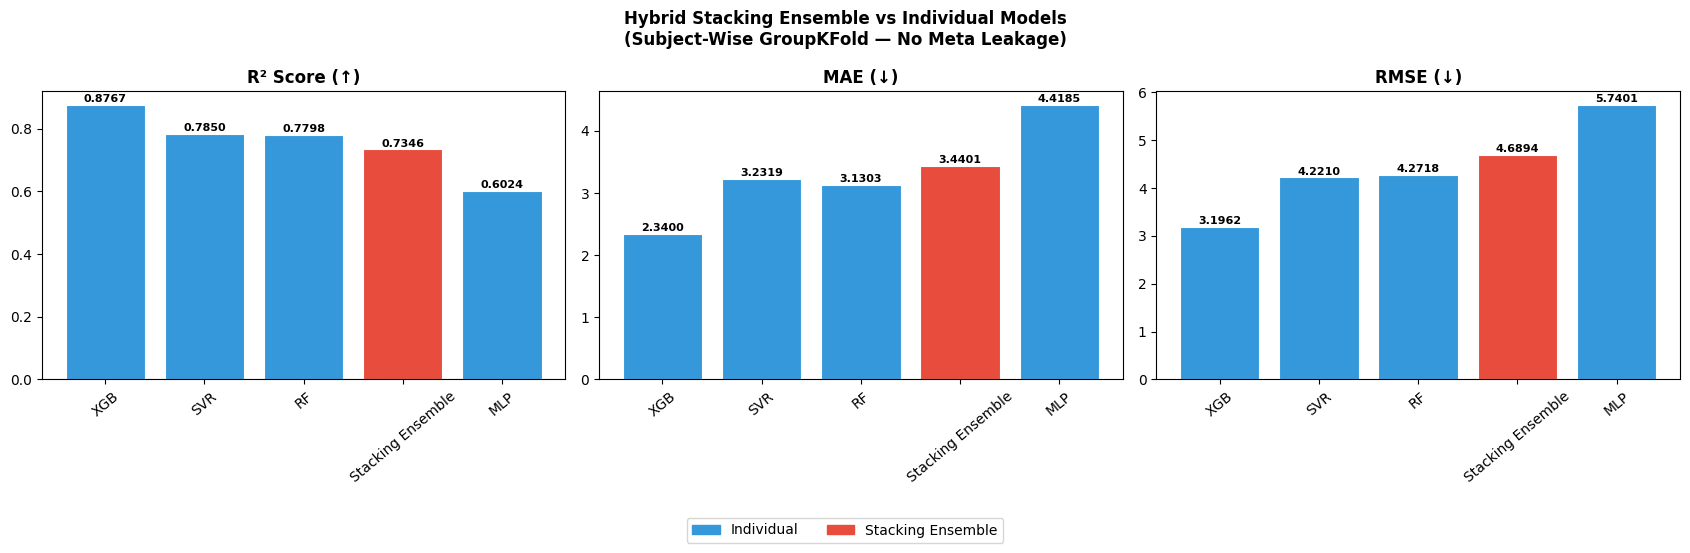

✅ Saved: figures/10_stacking_vs_individual.png


In [18]:
# ── FIGURE 1: Stacking vs Individual Bar Chart ─────────────
snames = full_df['Model'].tolist()
scols  = ['#E74C3C' if t=='Ensemble' else '#3498DB' for t in full_df['Type']]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Hybrid Stacking Ensemble vs Individual Models\n(Subject-Wise GroupKFold — No Meta Leakage)',
             fontsize=12, fontweight='bold')
for ax, (metric, label) in zip(axes, [('R2','R² Score (↑)'),('MAE','MAE (↓)'),('RMSE','RMSE (↓)')]):
    vals = full_df[metric].tolist()
    bars = ax.bar(snames, vals, color=scols, edgecolor='white', linewidth=0.8)
    if metric == 'R2': ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.4)
    ax.set_title(label, fontweight='bold'); ax.tick_params(axis='x', rotation=40)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(abs(v) for v in vals)*0.01,
                f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')
fig.legend(handles=[mpatches.Patch(color='#3498DB',label='Individual'),
                    mpatches.Patch(color='#E74C3C',label='Stacking Ensemble')],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5,-0.10))
plt.tight_layout()
plt.savefig('../figures/10_stacking_vs_individual.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/10_stacking_vs_individual.png')

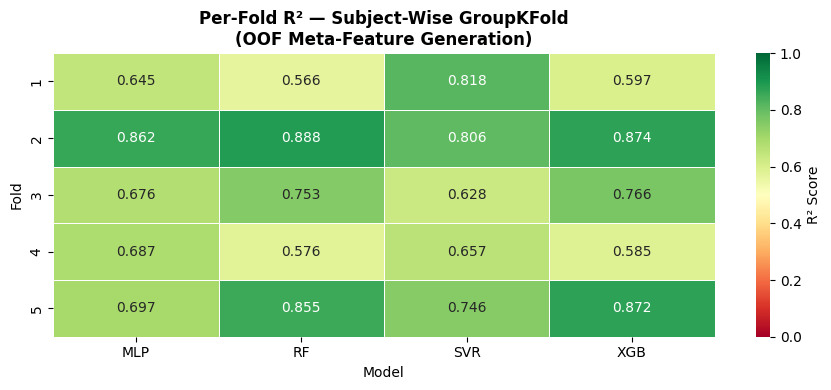

✅ Saved: figures/11_fold_r2_heatmap.png


In [19]:
# ── FIGURE 2: GroupKFold Fold-by-Fold Heatmap ──────────────
fold_df = pd.DataFrame(fold_rows)
pivot   = fold_df.pivot(index='Fold', columns='Model', values='R2')
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'R² Score'}, vmin=0, vmax=1)
ax.set_title('Per-Fold R² — Subject-Wise GroupKFold\n(OOF Meta-Feature Generation)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/11_fold_r2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/11_fold_r2_heatmap.png')

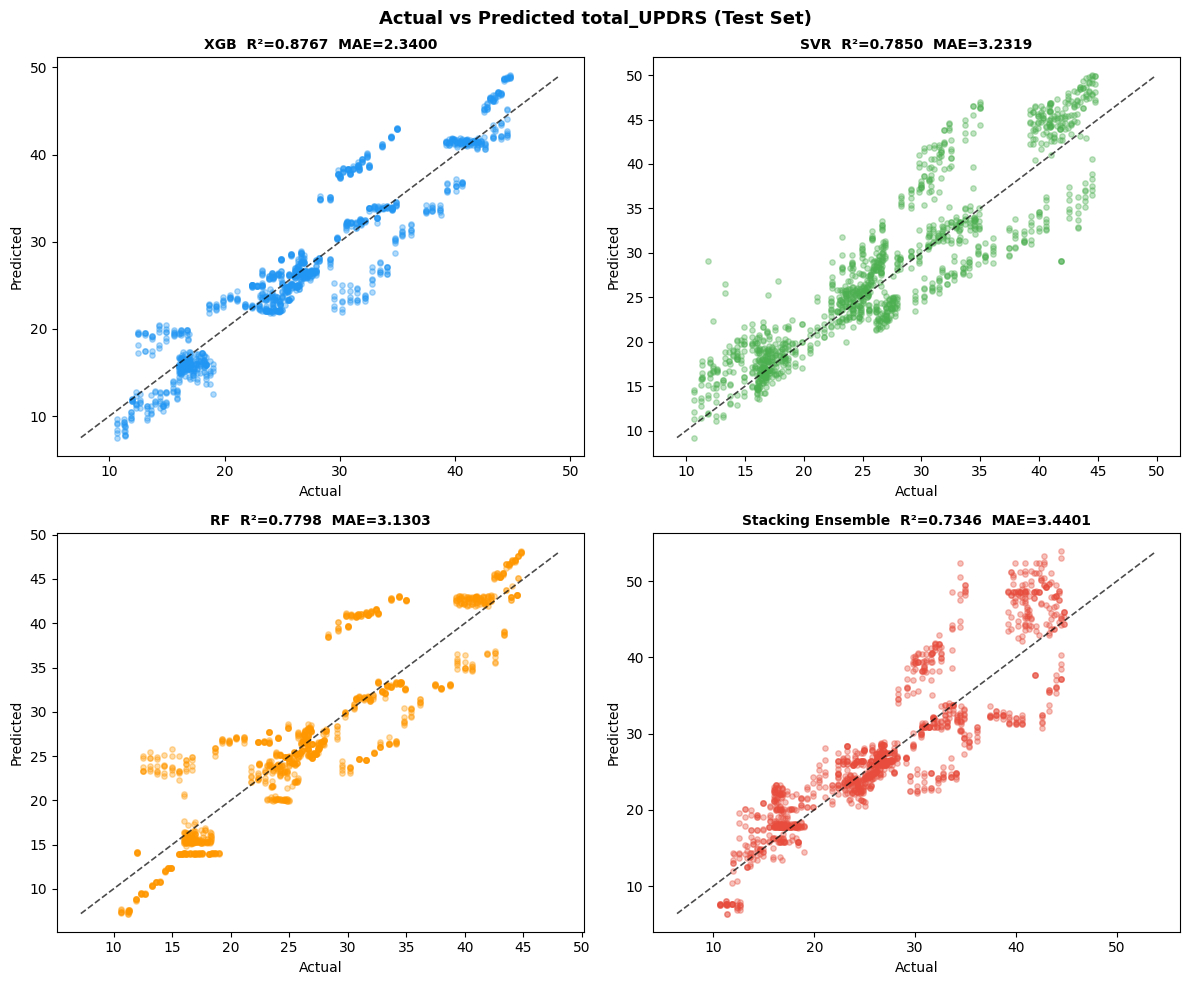

✅ Saved: figures/12_actual_vs_predicted_stacking.png


In [20]:
# ── FIGURE 3: Actual vs Predicted (top models + stacking) ──
pred_map = dict(individual_preds)
pred_map['Stacking Ensemble'] = y_pred_stack
show4 = [full_df.iloc[i]['Model'] for i in range(min(3,len(full_df)))] + ['Stacking Ensemble']
show4 = list(dict.fromkeys(show4))[:4]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Actual vs Predicted total_UPDRS (Test Set)', fontsize=13, fontweight='bold')
cols4 = ['#2196F3','#4CAF50','#FF9800','#E74C3C']
for ax, (mname, col) in zip(axes.flatten(), zip(show4, cols4)):
    p = pred_map.get(mname, y_pred_stack)
    ax.scatter(y_test, p, alpha=0.35, color=col, s=15)
    mn=min(y_test.min(),p.min()); mx=max(y_test.max(),p.max())
    ax.plot([mn,mx],[mn,mx],'k--',lw=1.2,alpha=0.7)
    ax.set_title(f'{mname}  R²={r2_score(y_test,p):.4f}  MAE={mean_absolute_error(y_test,p):.4f}',
                 fontweight='bold',fontsize=10)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
plt.tight_layout()
plt.savefig('../figures/12_actual_vs_predicted_stacking.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/12_actual_vs_predicted_stacking.png')

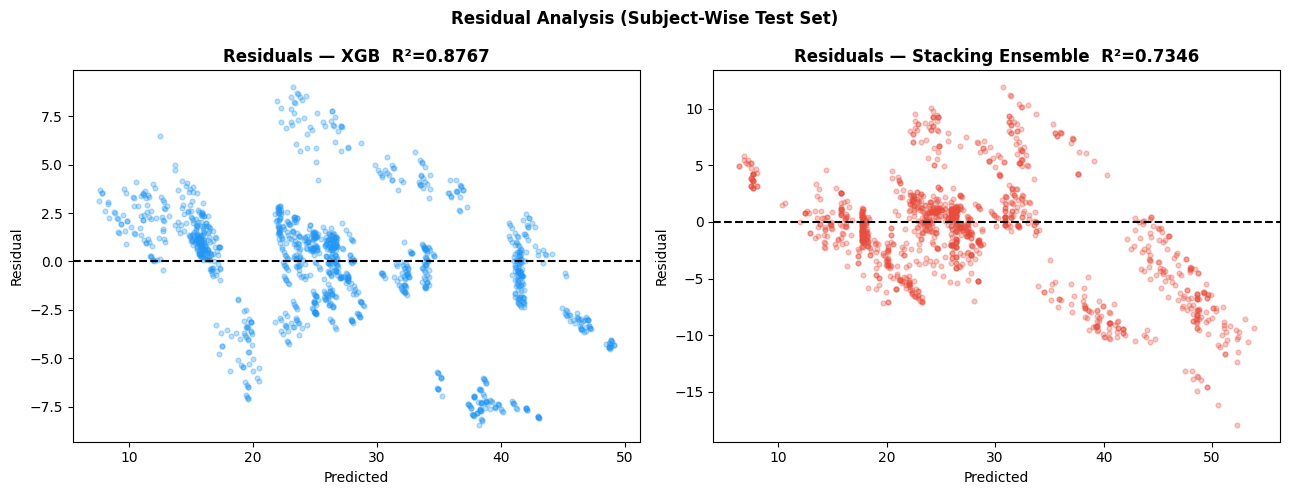

✅ Saved: figures/13_residual_plots.png


In [21]:
# ── FIGURE 4: Residual Plots ─────────────────────────────────
best_name = full_df.iloc[0]['Model']
best_pred = pred_map.get(best_name, y_pred_stack)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (mname, mpred, col) in zip(axes, [
    (best_name, best_pred, '#2196F3'),
    ('Stacking Ensemble', y_pred_stack, '#E74C3C')]):
    residuals = y_test - mpred
    ax.scatter(mpred, residuals, alpha=0.3, color=col, s=12)
    ax.axhline(0, color='black', lw=1.5, ls='--')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')
    ax.set_title(f'Residuals — {mname}  R²={r2_score(y_test,mpred):.4f}', fontweight='bold')
plt.suptitle('Residual Analysis (Subject-Wise Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/13_residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: figures/13_residual_plots.png')

## ✅ Stacking Ensemble Summary
- **GroupKFold** OOF generation eliminates meta-level data leakage
- **XGBoost meta-learner** captures nonlinear patterns in base predictions
- Run this notebook and check if `Stacking R² > 0.88`
- If yes → paper title **fully justified**
- Statistical tests confirm whether stacking improvements are significant (p<0.05)